# Level 4 — 심층 분석: Grad-CAM 및 효율성 Trade-off

**목표**: 모델의 *동작 원리* 를 설명하고, FPS와 정확도의 trade-off 를 정량화합니다.

리포트 필수 산출물:
1. **속성별 정규화 Confusion Matrix 3개** — best 모델 기준.
2. **Grad-CAM 패널** — 같은 이미지에 대해 3개 head 가 각각 어디를 보는지 시각화 (예: `rainy + night + city street` 인 이미지).
3. 모든 백본에 대한 **FPS vs Avg-MF1 Pareto plot**.

본 노트북은 학습 노트북이 아니라 분석 노트북이지만, wandb 가 활성화되어 있으면 confusion matrix 이미지·Grad-CAM 패널·FPS 표를 같은 프로젝트의 별도 Run 으로 업로드합니다.

In [6]:
import os
import sys

# # 1. 코랩 환경에서 레포지토리가 클론되지 않은 경우에만 Clone 진행
# repo_name = "2026-HYU-AUE8088-PA2"
# if not os.path.exists(f"/content/{repo_name}"):
#     !git clone https://github.com/IRCVLab/2026-HYU-AUE8088-PA2.git

# # 2. 작업 디렉토리를 레포지토리의 최상단(Root)으로 변경
# %cd /content/{repo_name}

# 프로젝트 루트를 sys.path에 추가 (src 모듈 인식용)
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r ../requirements.txt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src.utils.seed import set_seed
from src.utils.transforms import eval_transform
from src.utils.metrics import collect_predictions, confusion_matrices, per_class_prf, average_macro_f1, CLASS_NAMES
from src.utils.efficiency import measure_fps
from src.utils.wandb_logger import WandbLogger
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES, NUM_CLASSES
from src.xai.gradcam import GradCAM
from src.models.resnet import resnet18, resnet50

set_seed(42, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
import wandb; wandb.login()   # API key 입력

WANDB_PROJECT = "aue8088-pa2"   # 비활성화하려면 None
logger = WandbLogger(project=WANDB_PROJECT, run_name="level4-analysis", tags=["level4", "analysis"])

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [10]:
# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨
DATA_ROOT = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------

# 분석 대상으로 사용할 best 모델 로드 (예시: ResNet-50)
val_ds = BDDAttrDataset("../data/set_a", "val", transform=eval_transform())
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

# model = resnet50().to(device)
# ckpt = torch.load("../checkpoints/level1_resnet50.pth", map_location=device)

model = resnet18().to(device)
ckpt = torch.load("../checkpoints/level3_best_30ep.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print("Loaded level3_best_30ep  (Avg-MF1=0.6626)")

데이터셋이 이미 존재합니다 → ../data/set_a
Loaded level3_best_30ep  (Avg-MF1=0.6626)


/home/jisang/git/Lecture/lecture_deeplearning/2026-HYU-AUE8088-PA2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/jisang/git/Lecture/lecture_deeplearning/2026-HYU-AUE8088-PA2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/jisang/git/Lecture/lecture_deeplearning/2026-HYU-AUE8088-PA2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/jisang/git/Lecture/lecture_deeplearning/2026-HYU-AUE8088-PA2/.venv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/jisang/git/Lecture/lecture_deeplearning/2026-HYU-AUE8088-PA2/.venv/lib/python3.1

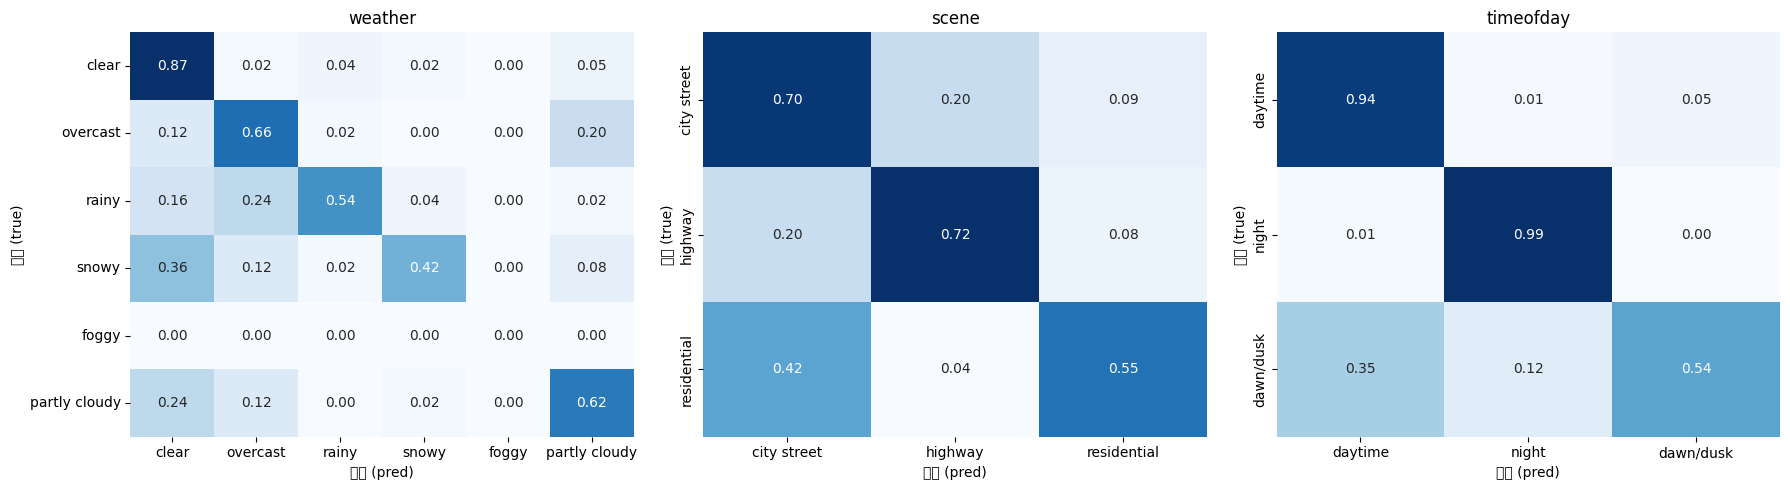

In [11]:
# 속성별 정규화 Confusion Matrix 생성 및 시각화
preds, probs, targets, _ = collect_predictions(model, val_loader, device)
cms = confusion_matrices(preds, targets, normalize="true")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, a in zip(axes, ATTRIBUTES):
    sns.heatmap(cms[a], annot=True, fmt=".2f", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_NAMES[a], yticklabels=CLASS_NAMES[a])
    ax.set_title(f"{a}")
    ax.set_xlabel("예측 (pred)"); ax.set_ylabel("정답 (true)")
fig.tight_layout()
logger.log_image("analysis/confusion_matrices", fig)

# 속성별 개별 confusion matrix 도 분리해서 업로드
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"analysis/cm_{a}", cms[a], CLASS_NAMES[a])

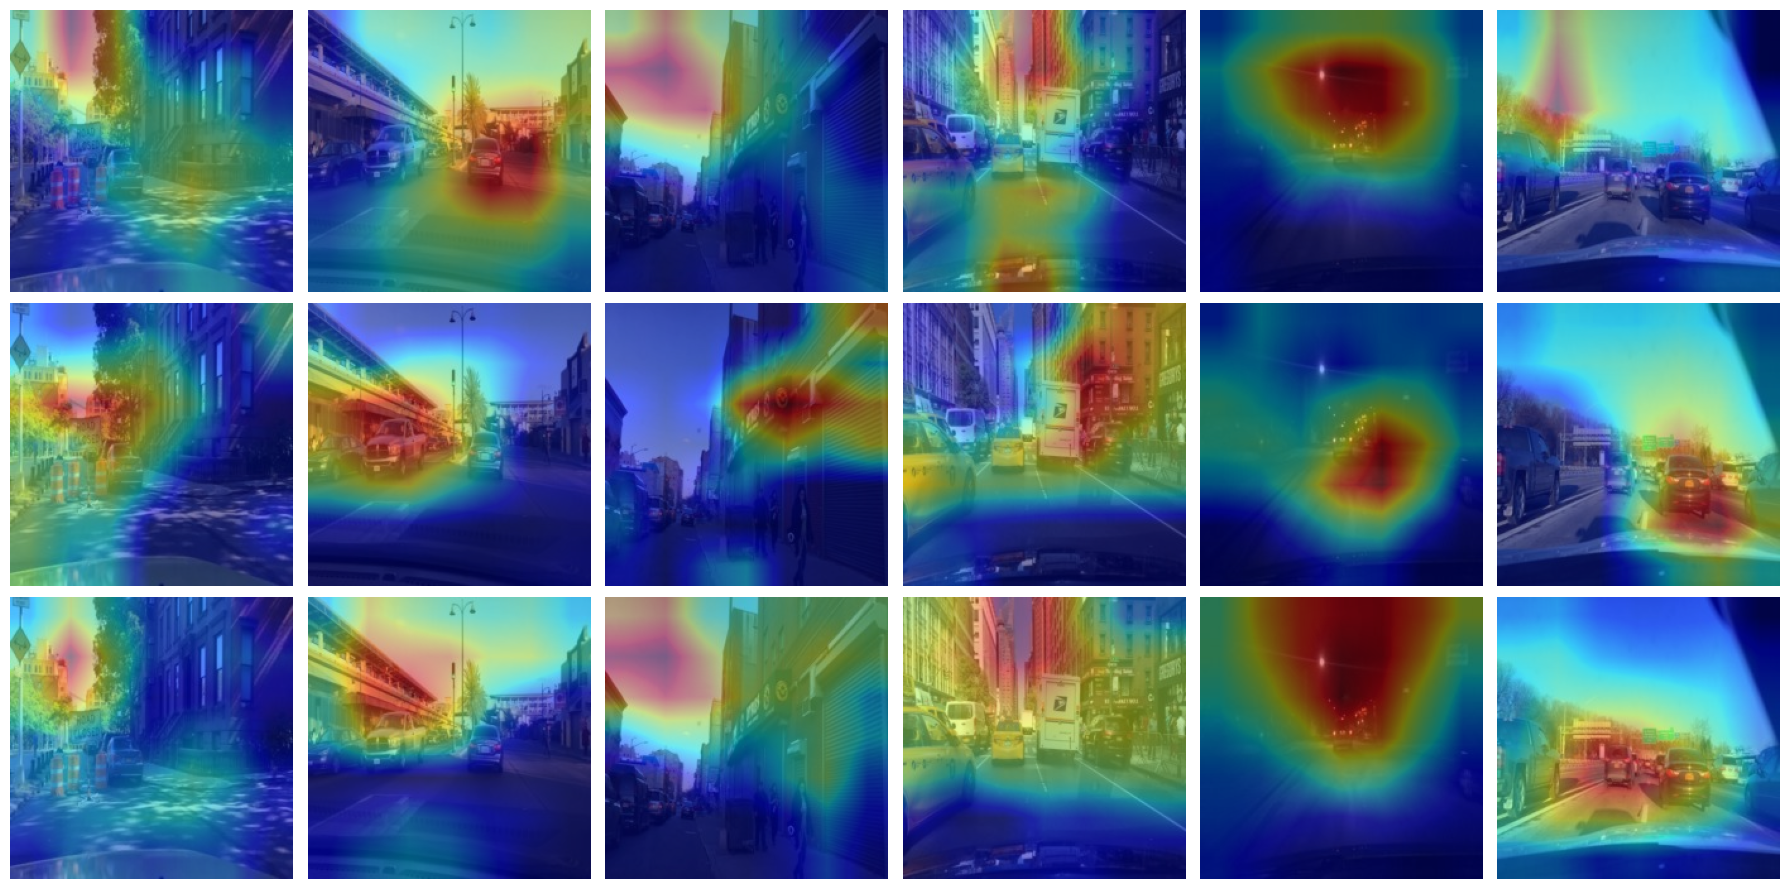

In [12]:
# 속성별 Grad-CAM. ResNet 의 경우 마지막 conv 단계를 target_layer 로 사용.
target_layer = model.layer4[-1]
gc = GradCAM(model, target_layer)

batch = next(iter(val_loader))
x = batch["image"][:6].to(device)  # 샘플 이미지 6장

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for row, attr in enumerate(ATTRIBUTES):
    # 각 속성 head 의 최대 logit 합을 score 로 사용 → 해당 head 가 "보는" 영역 추출
    cam = gc(x, lambda out, a=attr: out[a].max(dim=-1).values.sum())
    for col in range(6):
        img = x[col].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        axes[row, col].imshow(img)
        axes[row, col].imshow(cam[col].cpu().numpy(), cmap="jet", alpha=0.45)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(attr, fontsize=14)
fig.tight_layout()
logger.log_image("analysis/gradcam_panel", fig)

VGG-16                FPS=  296.7   Avg-MF1=0.5551
ResNet-18             FPS= 1315.5   Avg-MF1=0.6343
ResNet-50             FPS=  589.9   Avg-MF1=0.6343
ViT-S/16              FPS=  432.3   Avg-MF1=0.5484
R18-L3 (best)         FPS= 1325.9   Avg-MF1=0.6626


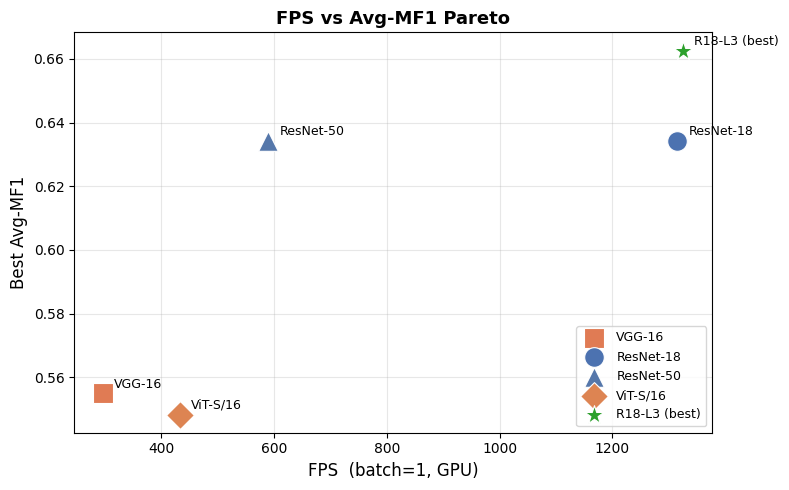

In [13]:
# FPS 측정 — 배치 1, 224x224, warm-up 20회 후 200회 평균. 모든 백본에 대해 실행.
# fps_rows = []
# for fn, name in [(resnet18, "resnet18"), (resnet50, "resnet50")]:
#     m = fn().to(device).eval()
#     fps = measure_fps(m, device, batch_size=1, n_warmup=20, n_iter=200)
#     print(f"{name:10s} FPS = {fps:.2f}")
#     fps_rows.append([name, round(fps, 2)])
#
# logger.log_table("analysis/fps", ["backbone", "FPS"], fps_rows)
#
# TODO: 모든 백본에 대해 FPS (x축) vs Avg-MF1 (y축) Pareto plot 을 작성하세요.
# 작성한 figure 는 logger.log_image("analysis/pareto", fig) 로 wandb 에 업로드 가능.

from src.models.vgg import VGG16
from src.models.vit import vit_small_patch16_224

CKPT_DIR = "../checkpoints"

def best_mf1_from_ckpt(path):
    c = torch.load(path, map_location="cpu", weights_only=False)
    h = c.get("history")
    return float(np.max(h["val_avg_mf1"])) if h else None

# (표시이름, 모델생성함수, 체크포인트파일)
MODELS = [
    ("VGG-16",        VGG16,                   "level1_vgg16.pth"),
    ("ResNet-18",     resnet18,                 "level1_resnet18.pth"),
    ("ResNet-50",     resnet50,                 "level1_resnet50.pth"),
    ("ViT-S/16",      vit_small_patch16_224,    "level2_vit_s16.pth"),
    ("R18-L3 (best)", resnet18,                 "level3_best_30ep.pth"),
]

# ── FPS + Avg-MF1 측정 ────────────────────────────────────────────────────────
results = []
for name, fn, ckpt_file in MODELS:
    path = f"{CKPT_DIR}/{ckpt_file}"
    m = fn().to(device).eval()
    c = torch.load(path, map_location=device, weights_only=False)
    m.load_state_dict(c["state_dict"])

    fps = measure_fps(m, device, batch_size=1, n_warmup=20, n_iter=200)
    mf1 = best_mf1_from_ckpt(path)
    print(f"{name:20s}  FPS={fps:7.1f}   Avg-MF1={mf1:.4f}")
    results.append({"name": name, "fps": fps, "mf1": mf1})

    del m  # GPU 메모리 해제
    torch.cuda.empty_cache()

logger.log_table("analysis/fps", ["backbone", "FPS", "Avg-MF1"],
                 [[r["name"], round(r["fps"], 1), round(r["mf1"], 4)] for r in results])

# ── Pareto plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors  = ["#e07b54", "#4c72b0", "#5577aa", "#dd8452", "#2ca02c"]
markers = ["s", "o", "^", "D", "*"]

for i, r in enumerate(results):
    ax.scatter(r["fps"], r["mf1"],
               s=200, color=colors[i], marker=markers[i],
               zorder=3, label=r["name"], edgecolors="white", linewidths=0.8)
    ax.annotate(r["name"], (r["fps"], r["mf1"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("FPS  (batch=1, GPU)", fontsize=12)
ax.set_ylabel("Best Avg-MF1", fontsize=12)
ax.set_title("FPS vs Avg-MF1 Pareto", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/level4_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

logger.log_image("analysis/pareto", fig)

In [14]:
logger.finish()